# Data Overview

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import numpy as np
import json
from utils import *
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib import patches
from tqdm import tqdm
import torch
import torchvision.transforms as transforms
from hirise_dtm import HiriseDTM

data_path = "data"
cave_catalog_path = os.path.join(data_path, "Mars_Extended_Cave_Catalog.csv")
deeplandforms_path = os.path.join(data_path, "DeepLandforms_dataset", "dataset.json")

## Mars Global Cave Candidate Catalog (MGC^3)

Integrated with elevations taken with pygmt: https://www.pygmt.org/latest/

G. E. Cushing. (2015). Mars Global Cave Candidate Catalog PDS4 Archive Bundle.  PDS Cartography and Imaging Sciences Node (IMG). https://doi.org/10.17189/1519222

In [2]:
cave_catalog = pd.read_csv(cave_catalog_path)
cave_catalog

,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation
0,APC001,240.4585,-0.94678,APC,1,25,32.0,APC -- tiny ~25m,5845.516289
1,APC003,237.6960,-12.47266,APC,1,30,47.0,APC 40m small deep nochain--big smrp?,10500.439389
2,APC005,240.8867,-5.68445,APC,1,30,17.0,APC deep pair,10144.570834
3,APC006,240.9421,-1.61377,APC,1,40,38.0,APC small deep?,6446.123804
4,APC007,241.2993,-1.68555,APC,1,40,28.0,"APC, deep? ~40m",6610.563531
...,...,...,...,...,...,...,...,...,...
1057,CC0926,161.1272,9.64587,crk,0,NaN,NaN,Cerberus fractures in HiRISE,-2767.424452
1058,CC0927,141.3146,30.56317,irr,0,NaN,NaN,Irregular surface hole,-1519.403413
1059,CC0928,141.3121,30.58740,crk,0,NaN,NaN,Small ambiguous hole in fracture,-1559.675572
1060,CC0929,242.9741,-0.26598,sky,1,NaN,NaN,"pair of 60-m pits in flow, 1km apart",6403.049279


## DeepLandforms

Source: https://zenodo.org/records/6818611?preview_file=DeepLandforms_demo_dataset.zip

In [3]:
with open(deeplandforms_path, 'r') as json_file:
    deep_landforms_metadata = json.load(json_file)
    deep_landforms_metadata_imgs = pd.DataFrame(deep_landforms_metadata["images"])
    deep_landforms_metadata_annotations = pd.DataFrame(deep_landforms_metadata["annotations"])
    deep_landforms_metadata_categories = pd.DataFrame(deep_landforms_metadata["categories"])

deep_landforms_metadata_imgs

,height,width,id,file_name
0,1728,1729,1,ESP_011386_2065_RED_resized_0.5_lbl_0.tiff
1,2116,2116,2,ESP_011386_2065_RED_resized_0.5_lbl_1.tiff
2,1212,1212,3,ESP_011386_2065_RED_resized_1_lbl_0.tiff
3,1540,1540,4,ESP_011386_2065_RED_resized_1_lbl_1.tiff
4,1008,1008,5,ESP_011386_2065_RED_resized_2_lbl_0.tiff
...,...,...,...,...
1831,2170,2170,1832,PSP_005691_1685_RED_resized_1_lbl_2.tiff
1832,1306,1306,1833,PSP_005691_1685_RED_resized_1_lbl_3.tiff
1833,1094,1094,1834,PSP_005691_1685_RED_resized_2_lbl_0.tiff
1834,1032,1032,1835,PSP_005691_1685_RED_resized_2_lbl_1.tiff


In [4]:
deep_landforms_metadata_annotations


,iscrowd,image_id,bbox,segmentation,category_id,id,area
0,0,1,"[438, 449, 830, 799]","[[673, 458, 507, 581, 465, 694, 438, 821, 466,...",0,1,532485
1,0,2,"[523, 535, 1048, 1016]","[[935, 565, 1031, 543, 1145, 535, 1242, 570, 1...",1,2,806355
2,0,3,"[399, 407, 415, 399]","[[517, 411, 434, 473, 413, 529, 399, 593, 414,...",0,3,133052
3,0,4,"[508, 516, 524, 508]","[[714, 531, 762, 520, 819, 516, 867, 533, 903,...",1,4,201337
4,0,5,"[400, 404, 208, 200]","[[459, 406, 417, 437, 407, 465, 400, 497, 407,...",0,5,33296
...,...,...,...,...,...,...,...
1841,0,1832,"[719, 726, 732, 719]","[[738, 1184, 719, 1100, 736, 1022, 775, 922, 8...",1,1842,417164
1842,0,1833,"[420, 443, 467, 420]","[[420, 568, 476, 505, 534, 474, 558, 450, 629,...",1,1843,137967
1843,0,1834,"[421, 378, 252, 339]","[[425, 450, 436, 418, 464, 396, 487, 391, 501,...",2,1844,57638
1844,0,1835,"[352, 328, 328, 377]","[[394, 380, 414, 359, 458, 346, 493, 338, 548,...",1,1845,90816


In [5]:
deep_landforms_metadata_categories

,id,name,supercategory
0,0,Type-1,Type-1
1,1,Type-4,Type-4
2,2,Type-2,Type-2


In [6]:
counts = deep_landforms_metadata_annotations["category_id"].value_counts()
map = {0: "Type-1", 1: "Type-4", 2:"Type-2"}

print("LABEL COUNT")
for category_id, count in counts.items():
    label = map.get(category_id, "Unknown")
    print(f"{label}: {count}")

LABEL COUNT
Type-4: 657
Type-1: 625
Type-2: 564


In [7]:
# Initialize variables to accumulate mean and std
mean = torch.zeros(1)
std = torch.zeros(1)
num_pixels = 0

# Dictionary to keep track of image shapes
shapes = {}

# Loop through the global dataset
for _, row in tqdm(
    deep_landforms_metadata_imgs.iterrows(),
    desc="Collecting image dimensions and computing statistics",
    total=len(deep_landforms_metadata_imgs)
):
    img = Image.open(os.path.join("data", f'DeepLandforms_dataset/{row["file_name"]}'))

    transform = transforms.Compose([
        transforms.PILToTensor()
    ])

    img = transform(img).float()
    channels, height, width = img.shape

    # Update shape occurrences
    shape = (width, height)
    shapes[shape] = shapes.get(shape, 0) + 1

    # Compute the number of pixels per image
    num_pixels += height * width

    # Sum the mean values of each channel
    mean += img.view(channels, -1).mean(dim=1)

    # Sum the standard deviation of each channel
    std += img.view(channels, -1).std(dim=1)


# Divide the sum of means and std by the total number of images
mean /= len(deep_landforms_metadata_imgs)
std /= len(deep_landforms_metadata_imgs)


# Find smallest and biggest images based on total pixel count
smallest_shape = min(shapes, key=lambda s: s[0] * s[1])
biggest_shape = max(shapes, key=lambda s: s[0] * s[1])

######## Probability distribution of image size over dataset ########
size_counts = {shape[0]: count for shape, count in shapes.items()}

sizes = list(size_counts.keys())
counts = list(size_counts.values())
sum_counts = sum(counts)

probabilities = [count/sum_counts for count in counts]
size_probability_dist = {size: prob for size, prob in zip(sizes, probabilities)}


print("Mean and standard deviation of image channels:")
print(f"Mean: {mean}")
print(f"Std: {std}")

print("\nImage dimensions:")
print(f"Smallest image: {smallest_shape} "
      f"({smallest_shape[0] * smallest_shape[1]:,} pixels)")

print(f"Biggest image: {biggest_shape} "
      f"({biggest_shape[0] * biggest_shape[1]:,} pixels)")

print(f"Number of different image sizes: {len(shapes)}")

Mean and standard deviation of image channels:
Mean: tensor([139.3476])
Std: tensor([28.8609])

Image dimensions:
Smallest image: (146, 146) (21,316 pixels)
Biggest image: (3465, 3465) (12,006,225 pixels)
Number of different image sizes: 753


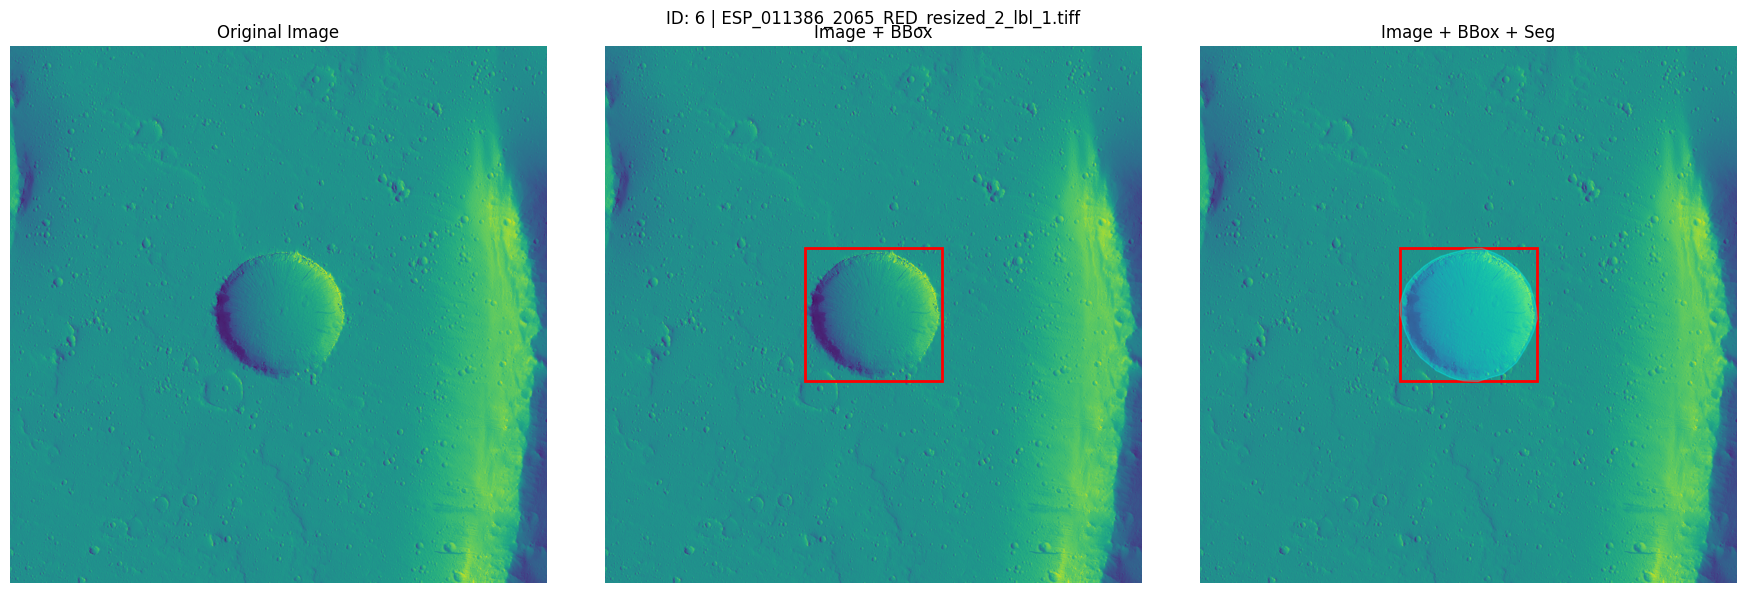

In [12]:
deep_landforms_metadata_annotations_copy = deep_landforms_metadata_annotations[deep_landforms_metadata_annotations["category_id"] == 1]
deep_landforms_metadata_annotations_copy.reset_index(inplace=True)

random_id = 2 # np.random.randint(len(deep_landforms_metadata_annotations_copy))
random_id = deep_landforms_metadata_annotations_copy.loc[random_id, "image_id"]

image_name = deep_landforms_metadata_imgs.loc[deep_landforms_metadata_imgs["id"] == random_id]["file_name"].item()
img_annotations = deep_landforms_metadata_annotations_copy.loc[deep_landforms_metadata_annotations_copy["image_id"] == random_id]

if img_annotations.empty:
    print(f"No annotations found for image ID {random_id}")

bounding_box = img_annotations["bbox"].iloc[0]
segmentation = img_annotations["segmentation"].iloc[0]

example = Image.open(f'data/DeepLandforms_dataset/{image_name}')
with open(f'data/DeepLandforms_dataset/{image_name.replace(".tiff", ".json")}') as json_file:
    example_json = json.load(json_file)
#print(example_json)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(example)
axs[0].set_title("Original Image")

axs[1].imshow(example)
x_min, y_min, width, height = bounding_box
rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='red', facecolor='none')
axs[1].add_patch(rect)
axs[1].set_title("Image + BBox")

axs[2].imshow(example)
rect2 = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='red', facecolor='none')
axs[2].add_patch(rect2)
if isinstance(segmentation, list):
    for sub_polygon in segmentation:
        poly_coords = np.array(sub_polygon).reshape(-1, 2)
        polygon = patches.Polygon(poly_coords, closed=True, linewidth=1, edgecolor='cyan', facecolor='cyan', alpha=0.3)
        axs[2].add_patch(polygon)
axs[2].set_title("Image + BBox + Seg")

for ax in axs:
    ax.axis('off')

plt.suptitle(f"ID: {random_id} | {image_name}")
plt.tight_layout()
plt.show()

Shape: (1112, 1112)


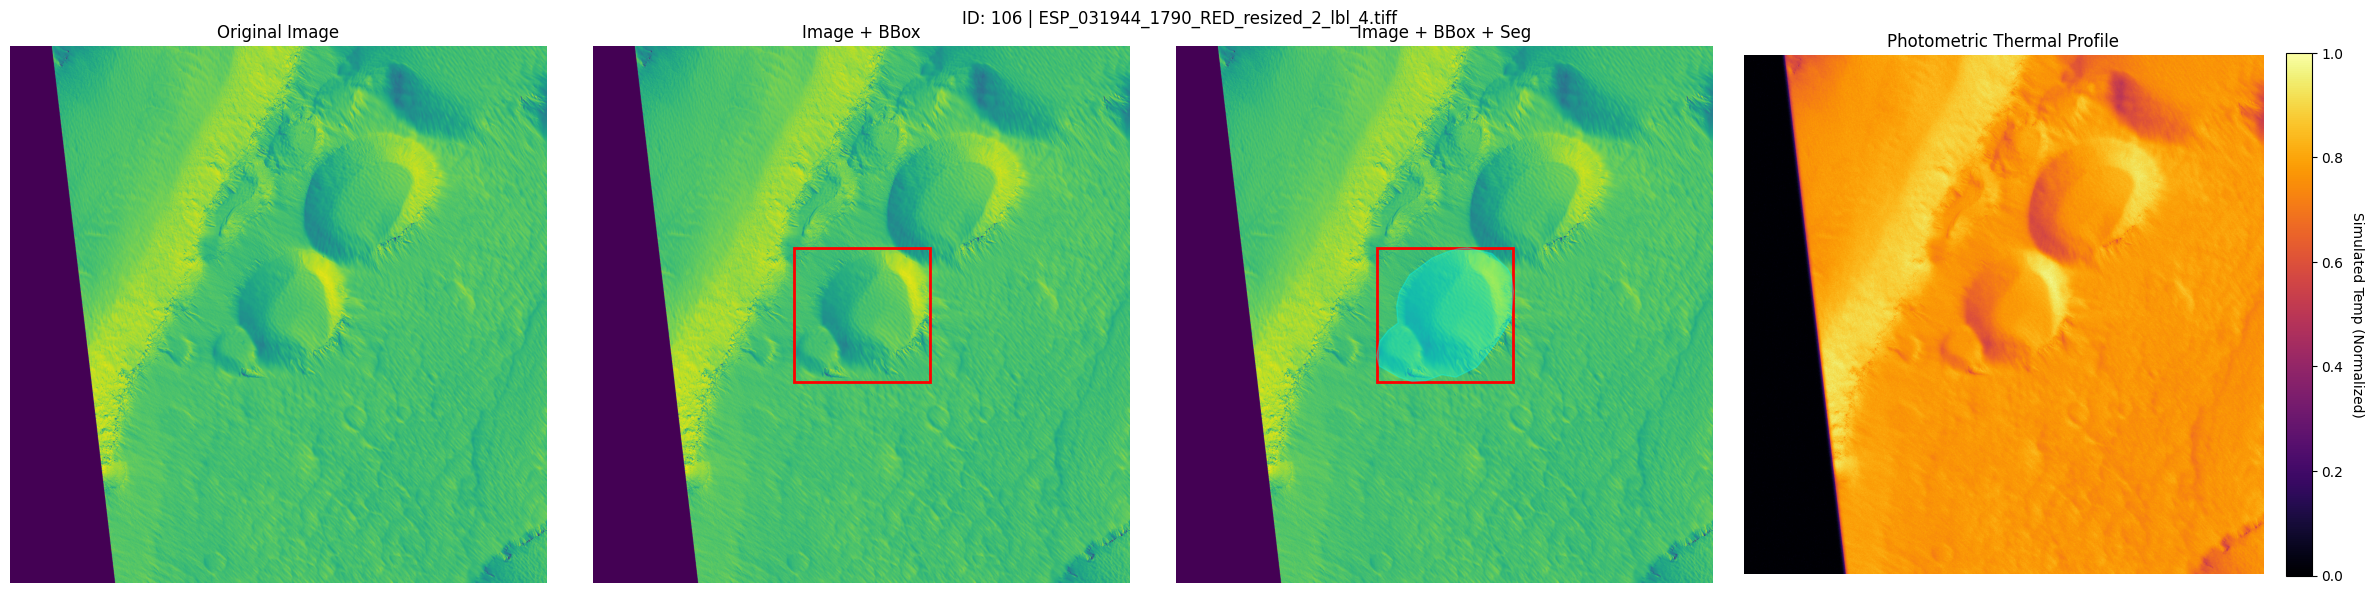

In [9]:
import json
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.ndimage import gaussian_filter

random_id = np.random.randint(len(deep_landforms_metadata_annotations))
image_name = deep_landforms_metadata_imgs.loc[
    deep_landforms_metadata_imgs["id"] == random_id
]["file_name"].item()
img_annotations = deep_landforms_metadata_annotations.loc[
    deep_landforms_metadata_annotations["image_id"] == random_id
]

if img_annotations.empty:
    print(f"No annotations found for image ID {random_id}")

bounding_box = img_annotations["bbox"].iloc[0]
segmentation = img_annotations["segmentation"].iloc[0]

example = Image.open(f"data/DeepLandforms_dataset/{image_name}")
with open(
    f'data/DeepLandforms_dataset/{image_name.replace(".tiff", ".json")}'
) as json_file:
    example_json = json.load(json_file)

# ---------------------------------------------------------
# 1. MASK-INDEPENDENT THERMAL SYNTHESIS
# ---------------------------------------------------------
gray_light = np.array(example.convert("L"), dtype=np.float32) / 255.0
print(f"Shape: {gray_light.shape}")

# A. Non-linear Radiative Response:
# Sunlit terrain (high light) reaches high surface temps (~0.85-1.0).
# Shallow illuminated craters stay moderately warm (~0.5-0.7).
# Deep, dark shadows (low light) drop to cold thermal baselines (~0.15-0.3).
radiative_temp = np.power(gray_light, 0.75)

# B. Thermal Diffusion (Heat Conduction):
# Thermal infrared images have lower spatial frequencies than optical images.
# Blurring simulates conductive heat spreading into adjacent regolith and shadows.
thermal_diffused = gaussian_filter(radiative_temp, sigma=4.0)

# C. Detail Preservation & Sensor Noise:
# Combine 70% diffuse thermal field with 30% local detail + sensor noise
noise = np.random.normal(0, 0.012, gray_light.shape)
thermal_synth = np.clip(0.70 * thermal_diffused + 0.30 * radiative_temp + noise, 0, 1)

# ---------------------------------------------------------
# 2. PLOT ALL 4 SUBPLOTS
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 4, figsize=(24, 6))

# Subplot 1: Original Image
axs[0].imshow(example)
axs[0].set_title("Original Image")

# Subplot 2: Image + Bounding Box
axs[1].imshow(example)
x_min, y_min, width, height = bounding_box
rect = patches.Rectangle(
    (x_min, y_min), width, height, linewidth=2, edgecolor="red", facecolor="none"
)
axs[1].add_patch(rect)
axs[1].set_title("Image + BBox")

# Subplot 3: Image + Bounding Box + Segmentation
axs[2].imshow(example)
rect2 = patches.Rectangle(
    (x_min, y_min), width, height, linewidth=2, edgecolor="red", facecolor="none"
)
axs[2].add_patch(rect2)
if isinstance(segmentation, list):
    for sub_polygon in segmentation:
        poly_coords = np.array(sub_polygon).reshape(-1, 2)
        polygon = patches.Polygon(
            poly_coords,
            closed=True,
            linewidth=1,
            edgecolor="cyan",
            facecolor="cyan",
            alpha=0.3,
        )
        axs[2].add_patch(polygon)
axs[2].set_title("Image + BBox + Seg")

# Subplot 4: Image-Driven Thermal Profile
im4 = axs[3].imshow(thermal_synth, cmap="inferno", vmin=0, vmax=1)
axs[3].set_title("Photometric Thermal Profile")

# Colorbar Legend
cbar = fig.colorbar(im4, ax=axs[3], fraction=0.046, pad=0.04)
cbar.set_label("Simulated Temp (Normalized)", rotation=270, labelpad=15)

for ax in axs:
    ax.axis("off")

plt.suptitle(f"ID: {random_id} | {image_name}")
plt.tight_layout()
plt.show()


## Negatives

The negative class is cut from the DeepLandforms tiles themselves rather than
collected separately from other HiRISE products.

The earlier approach (`plain_data_collection.py`, sampling patches out of JP2
DTMs) produced negatives that differed from the labelled landforms in
resolution, ground footprint, pixel dtype and region of Mars. A classifier could
separate them on those differences alone, with no morphology at all: ground
extent by itself reached 88.5%, and all image statistics together 97.9%.
Normalising one artifact simply promoted the next.

Cutting a positive and a negative of identical size from the *same* tile removes
the whole family at once -- same product, same ISIS pipeline, same resolution
band, same dtype, same illumination, same footprint. Measured after the change,
acquisition features fall to 50.0% (chance) and all statistics together to 69.4%,
most of which is genuine: a pit casts a real shadow.

In [ ]:
from matched_crops import cut_pairs

# One positive/negative pair per tile. The positive is centred on the
# annotation and sized to hold it with margin; the negative comes from the
# widest strip of the same tile that clears every annotation on it.
REGENERATE_CROPS = False   # set True to re-cut (takes a few minutes)

matched_dir = os.path.join(data_path, "matched_crops")
matched_csv = os.path.join(matched_dir, "annotations.csv")

if REGENERATE_CROPS:
    landform_rows = deep_landforms_metadata_annotations.copy()
    landform_rows["image_name"] = [
        deep_landforms_metadata_imgs.loc[
            deep_landforms_metadata_imgs["id"] == i, "file_name"
        ].item()
        for i in landform_rows["image_id"]
    ]
    landform_rows["img_path"] = "data/DeepLandforms_dataset"

    matched_annotations = cut_pairs(landform_rows, out_dir=matched_dir)
    matched_annotations.to_csv(matched_csv, index=False)
else:
    matched_annotations = pd.read_csv(matched_csv)
    print(f"loaded {len(matched_annotations)} existing crops from {matched_dir}")

matched_annotations

## Training Dataset

In [ ]:
SAVE_DATASET = False

# The matched crops already carry their class (positives keep the landform's
# category, negatives get id 3), so the merge is just a coordinate pass.
merged_annotations = matched_annotations.copy()
merged_annotations["img_path"] = matched_dir.replace("\\", "/")

# Attach Mars coordinates and ground extent, computed once here and stored in
# image_dataset.json so downstream work never has to reopen a raster.
#
# center_latlon reads each crop's georeferencing and repairs a malformed CRS
# inherited from some HiRISE products, where the standard parallel was written
# into "latitude_of_origin" with "standard_parallel_1" left at 0. Read
# literally that offsets latitude by exactly the standard parallel -- up to
# 45 deg, about 2600 km. See themis_coordinates.py.
from themis_coordinates import center_latlon, ground_extent_m

geo = []
for row in tqdm(
    merged_annotations.itertuples(index=False),
    total=len(merged_annotations),
    desc="Coordinates",
):
    path = os.path.join(row.img_path, row.image_name)
    lat, lon = center_latlon(path)
    width_m, height_m = ground_extent_m(path)
    geo.append({
        "lat": lat, "lon_east": lon,
        "ground_width_m": width_m, "ground_height_m": height_m,
    })

merged_annotations = pd.concat(
    [merged_annotations.reset_index(drop=True), pd.DataFrame(geo)], axis=1
)

class_names = {
    0: "Vertical Pit/Skylight",
    1: "Shallow Pit Chain",
    2: "Sloped Pit",
    3: "Negative (same tile)",
}
print(merged_annotations["category_id"].map(class_names).value_counts().to_string())

if SAVE_DATASET:
    merged_annotations.to_json(
        os.path.join(data_path, "final_data", "image_dataset.json")
    )

merged_annotations

## JP2 Images

In [ ]:
filepath = "data/DTMs/ESP_043599_1650_RED.JP2"
dtm_file = HiriseDTM(filepath)
print(dtm_file.metadata)

dtm_file.plot_dtm()

In [ ]:
dtm_file.get_lat_lon(0, 0)

In [ ]:
image, (y,x) = dtm_file.get_portion_of_map(300)
dtm_file.show_image_portion(image)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

def scale_hirise_to_uint8(image: np.ndarray, fill_value: int = 0) -> np.ndarray:
    """
    Rescales valid HiRISE DN values (3 to 1021) to 8-bit uint8 (0 to 255).
    Special flags (0, 1, 2, 1022, 1023) and NaNs are assigned `fill_value`.

    :param image: Input NumPy array (float32 or uint16).
    :param fill_value: Value assigned to nodata/invalid pixels in the 8-bit output.
    :return: 8-bit array (dtype uint8) with values from 0 to 255.
    """
    # 1. Identify invalid pixels (NaNs, special PDS flags, out-of-bounds)
    invalid_mask = (
        np.isnan(image) |
        np.isin(image, [0, 1, 2, 1022, 1023]) |
        (image < 3) |
        (image > 1021)
    )

    # 2. Clip valid DN values strictly to the 3-1021 range
    clipped = np.clip(image, 3.0, 1021.0)

    # 3. Linear scale: (DN - min) / (max - min) * 255
    scaled = ((clipped - 3.0) / (1021.0 - 3.0)) * 255.0

    # 4. Convert to uint8
    uint8_img = np.round(scaled).astype(np.uint8)

    # 5. Set invalid/masked locations to the fill_value
    uint8_img[invalid_mask] = fill_value

    return uint8_img

merged_annotations_copy = merged_annotations[merged_annotations["category_id"] == 3].reset_index(drop=True)

if merged_annotations_copy.empty:
    print("No annotations found with category_id == 3.")
else:
    # 1. Sample a single random row object directly
    sample_row = merged_annotations_copy.sample(1).iloc[0]

    random_id = sample_row["image_id"]
    image_name = sample_row["image_name"]
    bounding_box = sample_row.get("bbox", [])
    segmentation = sample_row.get("segmentation", [])

    # 2. Load image
    example = Image.open(f'{sample_row["img_path"]}/{image_name}')
    example = scale_hirise_to_uint8(np.array(example))
    print(np.min(example))
    print(np.max(example))

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    # Panel 1: Original Image
    axs[0].imshow(example)
    axs[0].set_title("Original Image")

    # Panel 2: Image + BBox
    axs[1].imshow(example)
    if isinstance(bounding_box, (list, tuple, np.ndarray)) and len(bounding_box) == 4:
        x_min, y_min, width, height = bounding_box
        rect = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='red', facecolor='none')
        axs[1].add_patch(rect)
    axs[1].set_title("Image + BBox")

    # Panel 3: Image + BBox + Seg
    axs[2].imshow(example)
    if isinstance(bounding_box, (list, tuple, np.ndarray)) and len(bounding_box) == 4:
        x_min, y_min, width, height = bounding_box
        rect2 = patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='red', facecolor='none')
        axs[2].add_patch(rect2)

    if isinstance(segmentation, list):
        for sub_polygon in segmentation:
            if len(sub_polygon) > 0:
                poly_coords = np.array(sub_polygon).reshape(-1, 2)
                polygon = patches.Polygon(poly_coords, closed=True, linewidth=1, edgecolor='cyan', facecolor='cyan', alpha=0.3)
                axs[2].add_patch(polygon)
    axs[2].set_title("Image + BBox + Seg")

    for ax in axs:
        ax.axis('off')

    plt.suptitle(f"ID: {random_id} | {image_name}")
    plt.tight_layout()
    plt.show()